# Updated Hierarchical Model -- EDA, multicollinearity, and 5-scenario comparison

Builds on the earlier port of `Hier_Model.R`. This version adds:

1. The **EDA section copied from `ass1.ipynb`** (score distribution, linearity checks, categorical
   boxplots, correlation heatmap).
2. **Multicollinearity checks** (correlation heatmap + VIF) before vs. after feature engineering.
3. The hierarchical model's **MSE, R², and adjusted R²** compared across 5 scenarios:
   - Original (no feature engineering)
   - `log1p(absences)` only
   - `Dalc + Walc` combined feature only
   - `Medu x Fedu` interaction only
   - All features engineered together

**Assumptions worth checking against your R environment** (unchanged from before):
- `guardian_edu` / `age_std` from `Hier_Model.R` aren't in the raw `train.rds`/`test.rds`. This notebook
  uses `Medu` + `Fedu` directly in the family block, and standardises `age` inside each fold's pipeline.
- The `Dalc + Walc` feature (`alc_total = Dalc + Walc`) is new for this analysis -- it wasn't in
  `ass1.ipynb`. It follows the same "add the combination alongside the originals" pattern used for
  `Medu x Fedu`. Swap in a different combination (e.g. a weighted weekday/weekend average) if you had
  something else in mind.
- `baseline_lm_cv` from your R script isn't included here since it wasn't in the file you sent; the focus
  below is the hierarchical model itself across the 5 scenarios.

In [1]:
import numpy as np
import pandas as pd
import pyreadr

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# needed for the multicollinearity (VIF) section -- if not installed: %pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

SEED = 123      # matches set.seed(123) in Hier_Model.R
N_FOLDS = 10    # matches createFolds(..., k = 10)

train = pyreadr.read_r("train.rds")[None]
test  = pyreadr.read_r("test.rds")[None]

X_raw = train.drop(columns="score")
y = train["score"].to_numpy()
n = len(train)
print(train.shape, test.shape, "missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head()

(316, 31) (79, 30) missing values: 0 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18.0,U,GT3,T,3.0,2.0,other,services,...,yes,yes,5.0,4.0,3.0,2.0,3.0,1.0,7.0,0.648402
1,GP,F,17.0,U,GT3,T,3.0,4.0,services,other,...,yes,no,4.0,4.0,5.0,1.0,3.0,5.0,16.0,1.169019
2,GP,M,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,no,5.0,2.0,2.0,1.0,1.0,2.0,4.0,0.384039
3,GP,M,18.0,R,GT3,T,4.0,3.0,teacher,services,...,yes,yes,5.0,3.0,2.0,1.0,2.0,4.0,9.0,1.207493
4,GP,F,16.0,U,GT3,T,1.0,3.0,at_home,services,...,yes,yes,4.0,3.0,5.0,1.0,1.0,3.0,0.0,-1.215206


## 1. Exploratory data analysis

*(Copied from `ass1.ipynb`, unchanged.)*

Variance of score (= MSE of always predicting the mean): 0.97


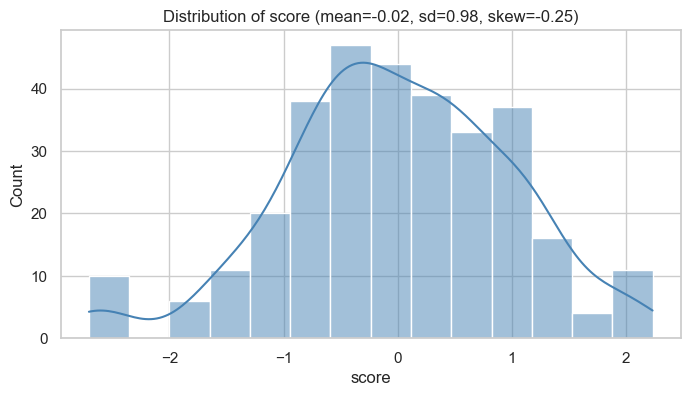

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train["score"], kde=True, ax=ax, color="steelblue")
ax.set_title(f"Distribution of score (mean={y.mean():.2f}, sd={y.std():.2f}, skew={stats.skew(y):.2f})")
print("Variance of score (= MSE of always predicting the mean):", round(y.var(), 3))

`score` looks standardised and roughly normal, so no target transformation is needed.
The MSE of the "predict the mean" baseline is about the variance of `score` (~0.97). Any useful model must beat that.

### Linearity check: numeric predictors (red = LOWESS smoother; a straight red line means a linear relation)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


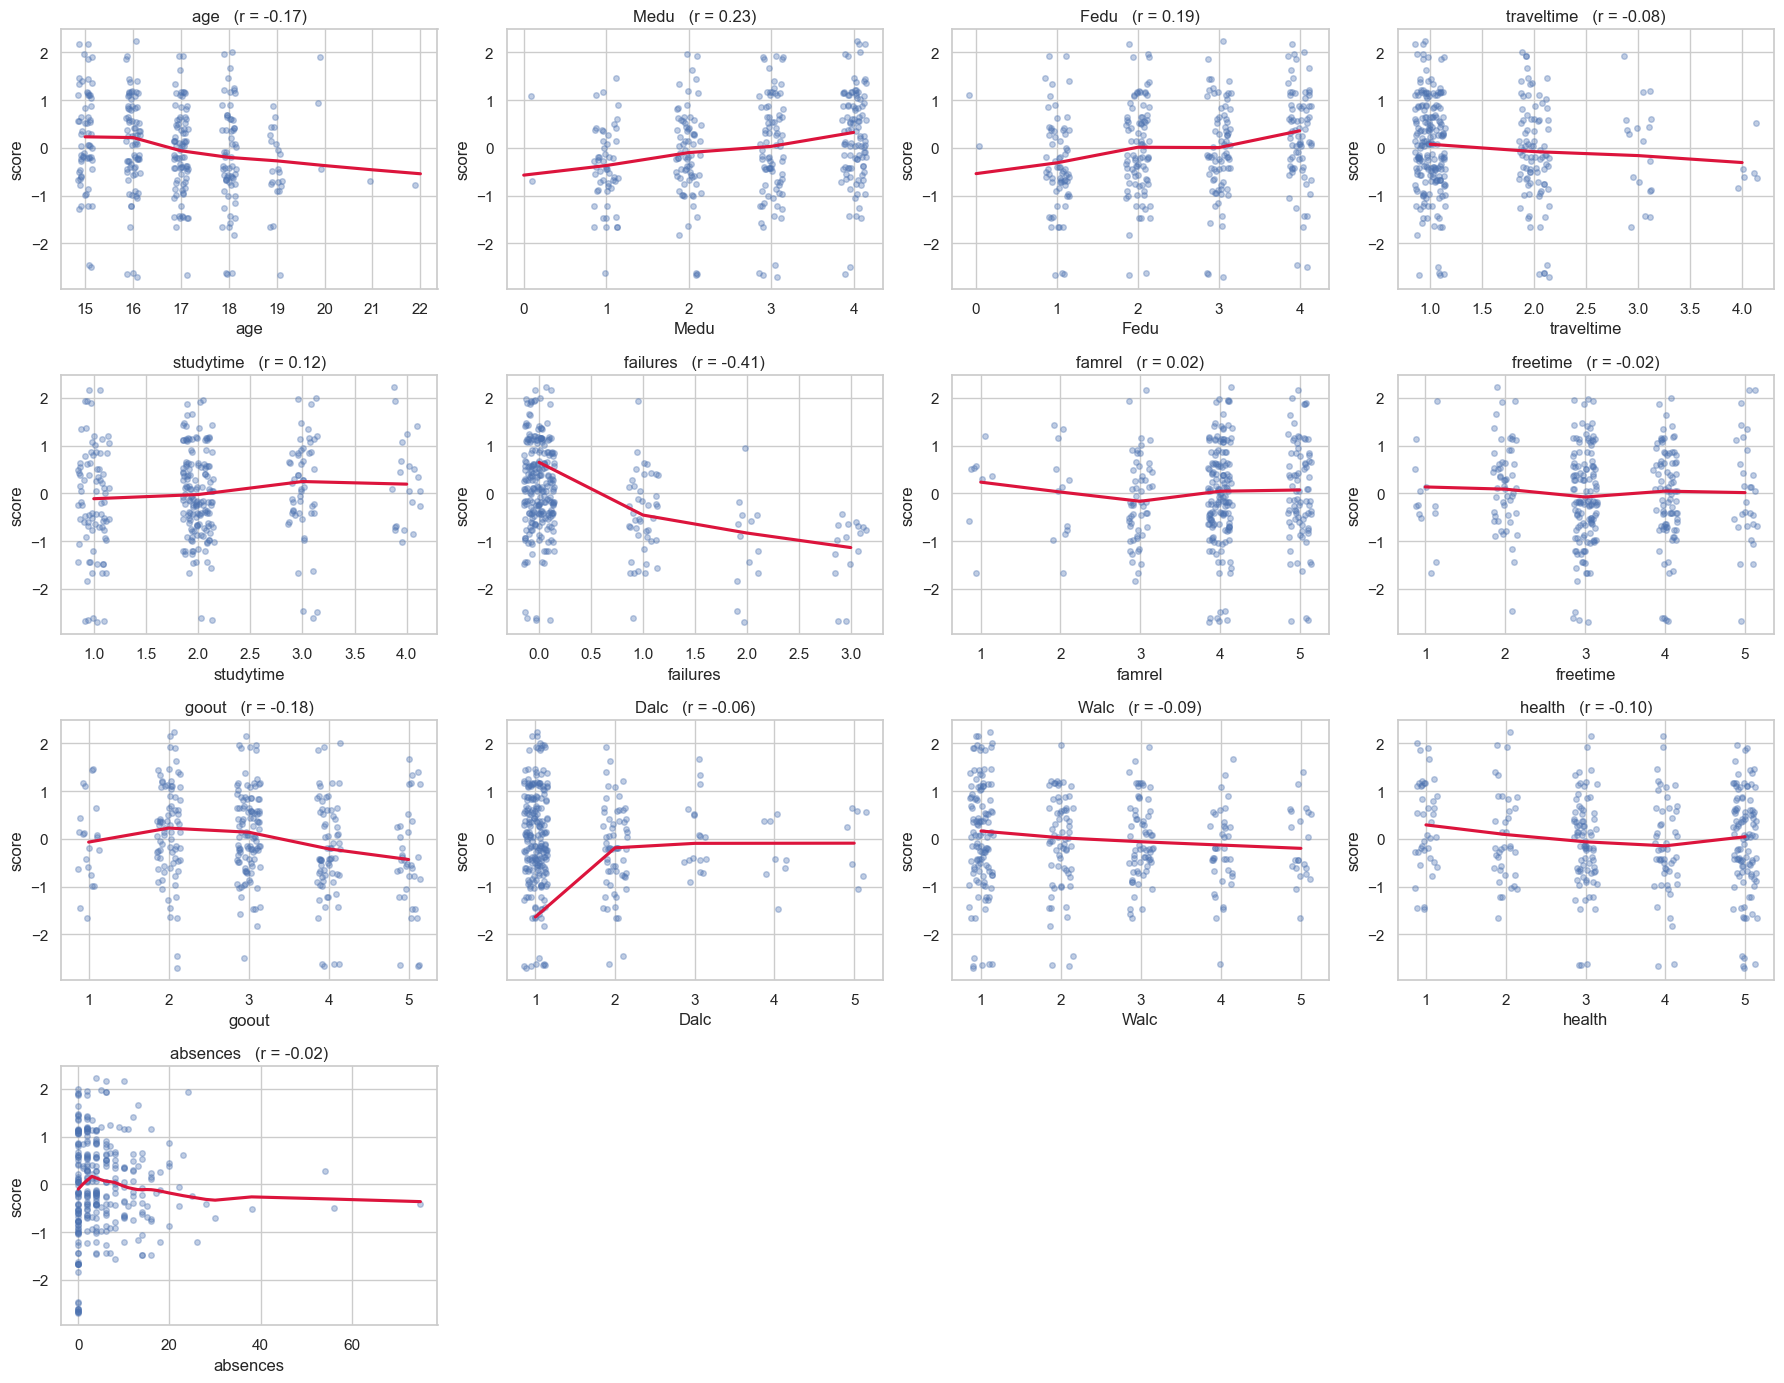

In [3]:
num_cols = X_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(18, 14)); axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.regplot(data=train, x=c, y="score", lowess=True, x_jitter=0.15 if train[c].nunique() <= 20 else 0,
                scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax)
    ax.set_title(f"{c}   (r = {train[c].corr(train['score']):.2f})")
for ax in axes[len(num_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Categorical predictors

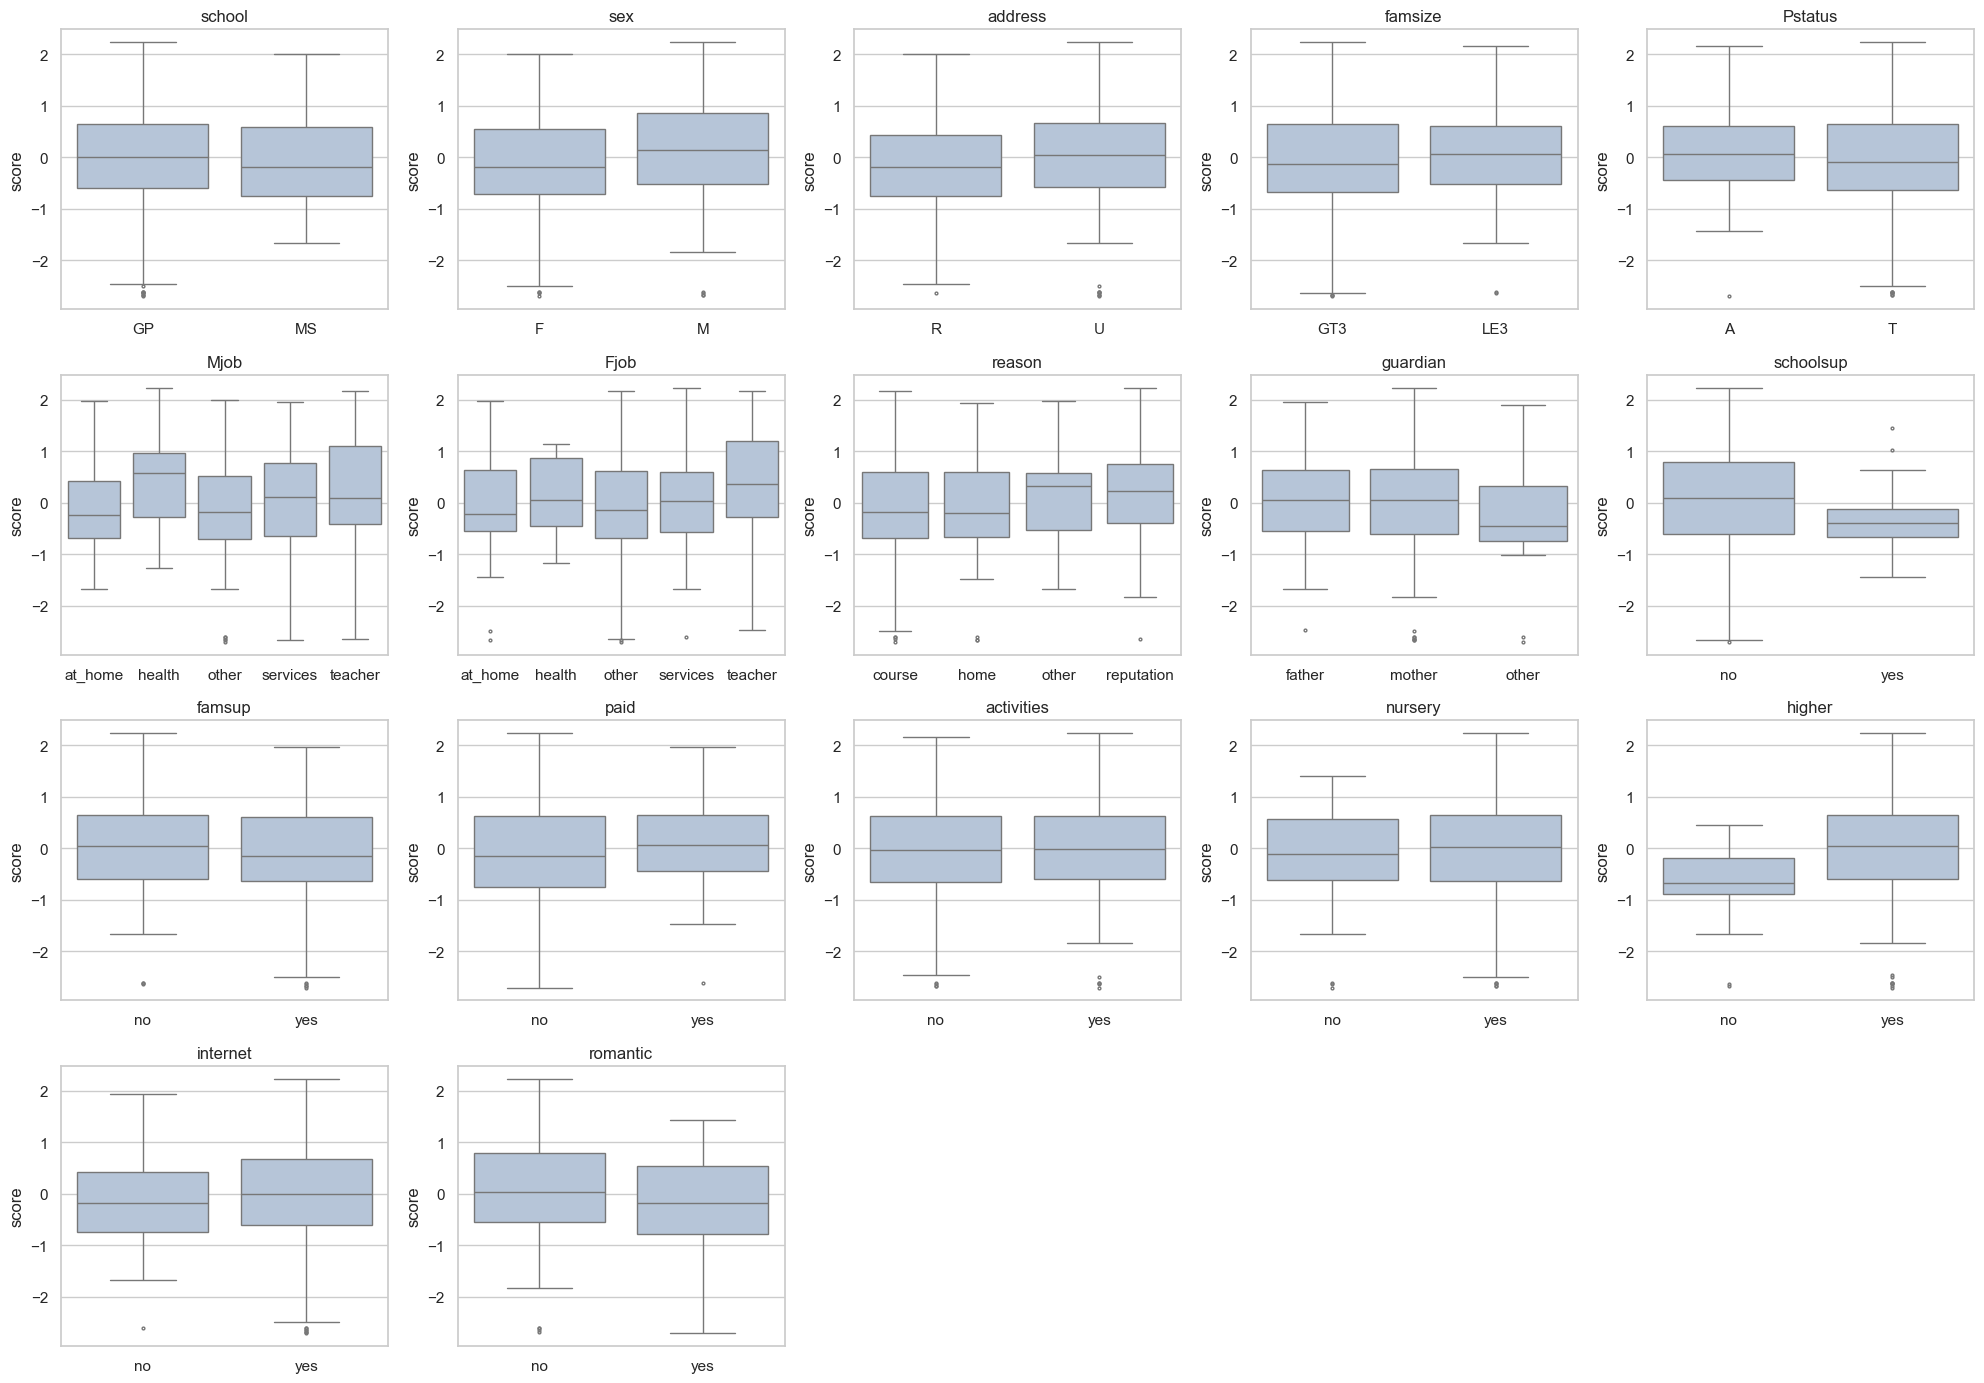

In [4]:
cat_cols = X_raw.select_dtypes("category").columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(20, 14)); axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=train, x=c, y="score", ax=ax, color="lightsteelblue", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
for ax in axes[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Which variables matter on their own? (univariate R² for numeric, η² for categorical) + correlation heatmap

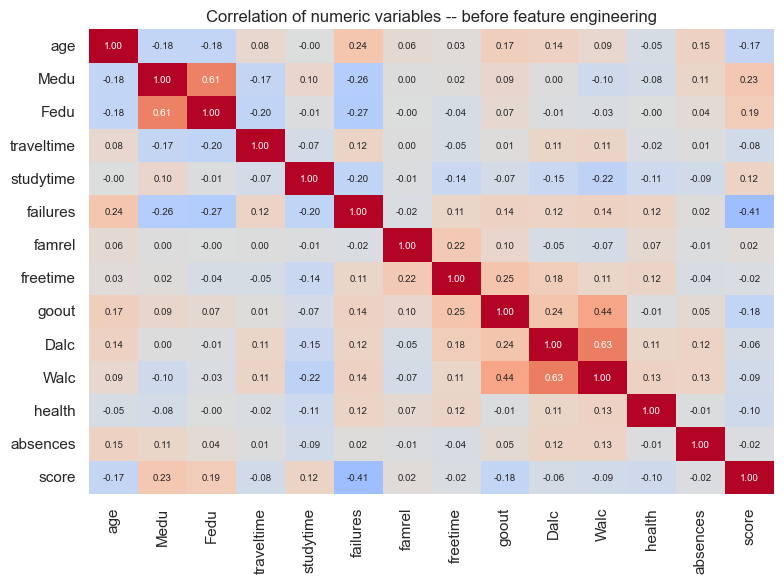

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables -- before feature engineering")
plt.tight_layout(); plt.show()

**What the plots say**
* Relationships are mostly weak and roughly linear. The strongest single signals are `failures` (clearly negative), `Medu`/`Fedu` and `Mjob` (positive), `goout` (negative), `higher`, `schoolsup`, `age`.
* `absences` is heavily right-skewed (many zeros, a few very large values) and shows no clear linear pattern, so it needs a transformation.
* The predictors are ordinal (1-5) with few levels, so linear trends are plausible but not guaranteed. The tree-based models test that.
* Because the signal is weak, expect a modest R². A large gap between train and CV error would be the main risk, which favours regularised models.

## 2. Feature engineering (parameterised)

`build_engineered()` generalises the `engineer()` function from `ass1.ipynb` into independent switches, so
each requested scenario can be built by turning specific steps on or off:

| Flag | Effect |
|---|---|
| `log_absences` | replaces `absences` with `log1p(absences)` in the academic block |
| `no_absences_flag` | adds a `(absences == 0)` indicator to the academic block |
| `had_failure` | adds a `(failures > 0)` indicator to the academic block, alongside raw `failures` |
| `medu_fedu` | adds the `Medu x Fedu` interaction to the family block, alongside `Medu` and `Fedu` |
| `alc_combo` | adds `alc_total = Dalc + Walc` to the lifestyle block, alongside `Dalc` and `Walc` |

In [6]:
def build_engineered(df, log_absences=False, no_absences_flag=False, had_failure=False,
                      medu_fedu=False, alc_combo=False):
    d = df.copy()

    academic_cols = ["school", "reason", "studytime", "failures", "schoolsup", "paid", "higher", "traveltime"]
    if log_absences:
        d["log_absences"] = np.log1p(d["absences"])
        academic_cols.append("log_absences")
    else:
        academic_cols.append("absences")
    if no_absences_flag:
        d["no_absences"] = (d["absences"] == 0).astype(float)
        academic_cols.append("no_absences")
    if had_failure:
        d["had_failure"] = (d["failures"] > 0).astype(float)
        academic_cols.append("had_failure")

    family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    if medu_fedu:
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols.append("Medu_x_Fedu")

    lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                      "internet", "freetime", "goout", "Dalc", "Walc"]
    if alc_combo:
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols.append("alc_total")

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS = {
    "1. Original (no engineering)": dict(),
    "2. log1p(absences)":           dict(log_absences=True),
    "3. Dalc + Walc combo":         dict(alc_combo=True),
    "4. Medu x Fedu interaction":   dict(medu_fedu=True),
    "5. All features engineered":  dict(log_absences=True, no_absences_flag=True,
                                         had_failure=True, medu_fedu=True, alc_combo=True),
}

## 3. Multicollinearity check: before vs. after feature engineering

The correlation heatmap above (section 1) is the **before** picture on the raw numeric predictors. Below,
the same heatmap is rebuilt on the **fully engineered** numeric predictors (scenario 5), and both are backed
up with **Variance Inflation Factors (VIF)** -- a single pairwise correlation can hide multivariate
collinearity that VIF picks up.

**What to expect:** `Medu_x_Fedu` and `alc_total` are *built from* `Medu`/`Fedu` and `Dalc`/`Walc`, so their
VIFs -- and those of their parent columns -- should rise; that's an expected side-effect of adding an
interaction/combination term, not a modelling error. `log1p(absences)` mainly fixes skew and linearity, so
it should barely move VIF.

In [7]:
numeric_before = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
                  "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]

X_vif_before = add_constant(train[numeric_before].astype(float))
vif_before = pd.DataFrame({
    "feature": X_vif_before.columns,
    "VIF": [variance_inflation_factor(X_vif_before.values, i) for i in range(X_vif_before.shape[1])]
}).query("feature != \'const\'").sort_values("VIF", ascending=False).reset_index(drop=True)
vif_before

,feature,VIF
0,Walc,2.146703
1,Medu,1.789436
2,Dalc,1.769676
3,Fedu,1.719347
4,goout,1.440119
5,failures,1.231015
6,freetime,1.197911
7,age,1.176302
8,studytime,1.133535
9,famrel,1.086060


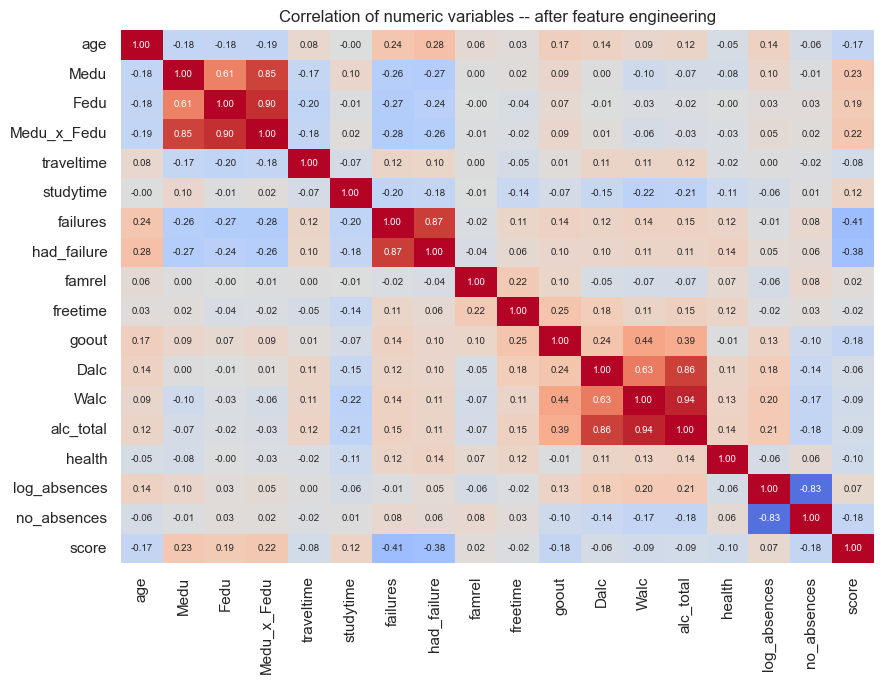

In [8]:
train_full_eng, academic_cols_full, family_cols_full, lifestyle_cols_full = build_engineered(
    X_raw, **SCENARIOS["5. All features engineered"])
train_full_eng["score"] = y

numeric_after = ["age", "Medu", "Fedu", "Medu_x_Fedu", "traveltime", "studytime", "failures", "had_failure",
                 "famrel", "freetime", "goout", "Dalc", "Walc", "alc_total", "health",
                 "log_absences", "no_absences"]

plt.figure(figsize=(9, 7))
sns.heatmap(train_full_eng[numeric_after + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables -- after feature engineering")
plt.tight_layout(); plt.show()

In [9]:
X_vif_after = add_constant(train_full_eng[numeric_after].astype(float))
vif_after = pd.DataFrame({
    "feature": X_vif_after.columns,
    "VIF": [variance_inflation_factor(X_vif_after.values, i) for i in range(X_vif_after.shape[1])]
}).query("feature != \'const\'").sort_values("VIF", ascending=False).reset_index(drop=True)
vif_after

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,Dalc,inf
1,alc_total,inf
2,Walc,inf
3,Medu_x_Fedu,25.101629
4,Fedu,11.040193
5,Medu,7.890610
6,had_failure,4.326681
7,failures,4.280777
8,log_absences,3.722705
9,no_absences,3.534670


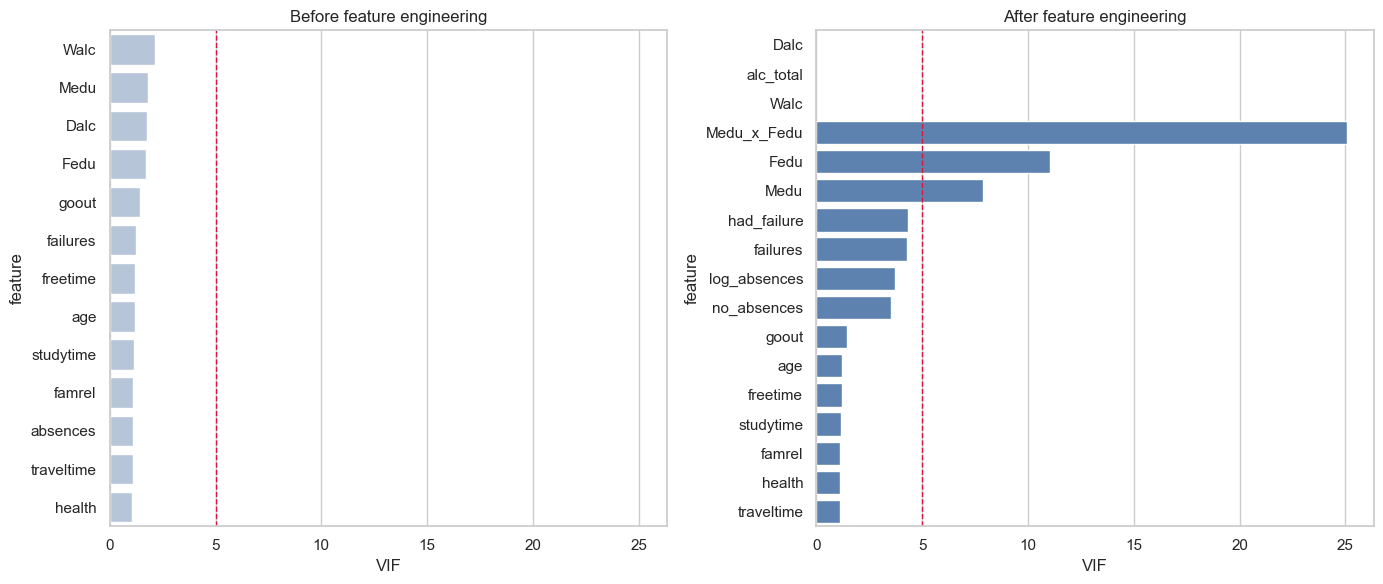

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
sns.barplot(data=vif_before, y="feature", x="VIF", ax=ax[0], color="lightsteelblue")
ax[0].axvline(5, color="crimson", ls="--", lw=1); ax[0].set_title("Before feature engineering")
sns.barplot(data=vif_after, y="feature", x="VIF", ax=ax[1], color="#4f81bd")
ax[1].axvline(5, color="crimson", ls="--", lw=1); ax[1].set_title("After feature engineering")
plt.tight_layout(); plt.show()

## 4. Hierarchical model pipeline (shared across all scenarios)

**How adjusted R² is computed here:** it's derived once per scenario from the average out-of-sample CV R²,
using `n` = total training rows and `p` = total number of encoded parameters spent across the three
sub-models plus the master regression's 3 proxy coefficients (reported as `n_params` in the results table).
This is a practical stand-in for the usual in-sample adjusted R² -- it rewards a scenario only if it improves
CV R² without a proportionally large increase in encoded parameters.

In [11]:
def make_sub_pipeline(cols, df_for_dtypes):
    cat_cols = [c for c in cols if str(df_for_dtypes[c].dtype) in ("category", "object")]
    ct = ColumnTransformer(
        [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat_cols)],
        remainder="passthrough")
    return Pipeline([("ct", ct), ("lm", LinearRegression())])


def count_encoded_features(cols, df_eng):
    """Number of columns a block contributes AFTER one-hot encoding -- used for adjusted R^2."""
    pipe = make_sub_pipeline(cols, df_eng)
    pipe.fit(df_eng[cols], df_eng["score"])
    return pipe.named_steps["ct"].transform(df_eng[cols]).shape[1]


def run_hier_cv(df_eng, academic_cols, family_cols, lifestyle_cols, kf):
    blocks = {"academic": academic_cols, "family": family_cols, "lifestyle": lifestyle_cols}
    fold_mse, fold_r2 = [], []

    for train_idx, test_idx in kf.split(df_eng):
        cv_train = df_eng.iloc[train_idx]
        cv_test  = df_eng.iloc[test_idx]

        proxies_train, proxies_test = {}, {}
        for name, cols in blocks.items():
            sub_pipe = make_sub_pipeline(cols, cv_train)
            sub_pipe.fit(cv_train[cols], cv_train["score"])
            proxies_train[f"{name}_proxy"] = sub_pipe.predict(cv_train[cols])
            proxies_test[f"{name}_proxy"]  = sub_pipe.predict(cv_test[cols])

        master_train = pd.DataFrame(proxies_train, index=cv_train.index)
        master_test  = pd.DataFrame(proxies_test, index=cv_test.index)

        master = LinearRegression().fit(master_train, cv_train["score"])
        preds = master.predict(master_test)

        fold_mse.append(float(np.mean((preds - cv_test["score"].to_numpy()) ** 2)))
        fold_r2.append(float(r2_score(cv_test["score"], preds)))

    cv_mse = float(np.mean(fold_mse))
    cv_r2  = float(np.mean(fold_r2))

    p_total = sum(count_encoded_features(cols, df_eng) for cols in blocks.values()) + 3
    n_total = len(df_eng)
    adj_r2 = 1 - (1 - cv_r2) * (n_total - 1) / (n_total - p_total - 1)

    return dict(CV_MSE=cv_mse, CV_R2=cv_r2, Adjusted_R2=adj_r2, n_params=p_total)

## 5. Compare hierarchical model performance across the 5 feature-engineering scenarios

The same 10 folds (`kf`, seeded) are reused for every scenario, so the comparison is paired: any difference
in MSE / R² / adjusted R² comes from the feature-engineering choice, not from different train/test splits.

In [12]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

rows = []
for scenario_name, flags in SCENARIOS.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered(X_raw, **flags)
    df_eng["score"] = y
    metrics = run_hier_cv(df_eng, academic_cols, family_cols, lifestyle_cols, kf)
    rows.append(dict(scenario=scenario_name, **metrics))

results = pd.DataFrame(rows).set_index("scenario")
results.round(4)

,CV_MSE,CV_R2,Adjusted_R2,n_params
scenario,,,,
1. Original (no engineering),0.8268,0.1005,-0.0494,45
2. log1p(absences),0.8198,0.1052,-0.0440,45
3. Dalc + Walc combo,0.8268,0.1005,-0.0533,46
4. Medu x Fedu interaction,0.8284,0.0986,-0.0555,46
5. All features engineered,0.7986,0.1311,-0.0289,49


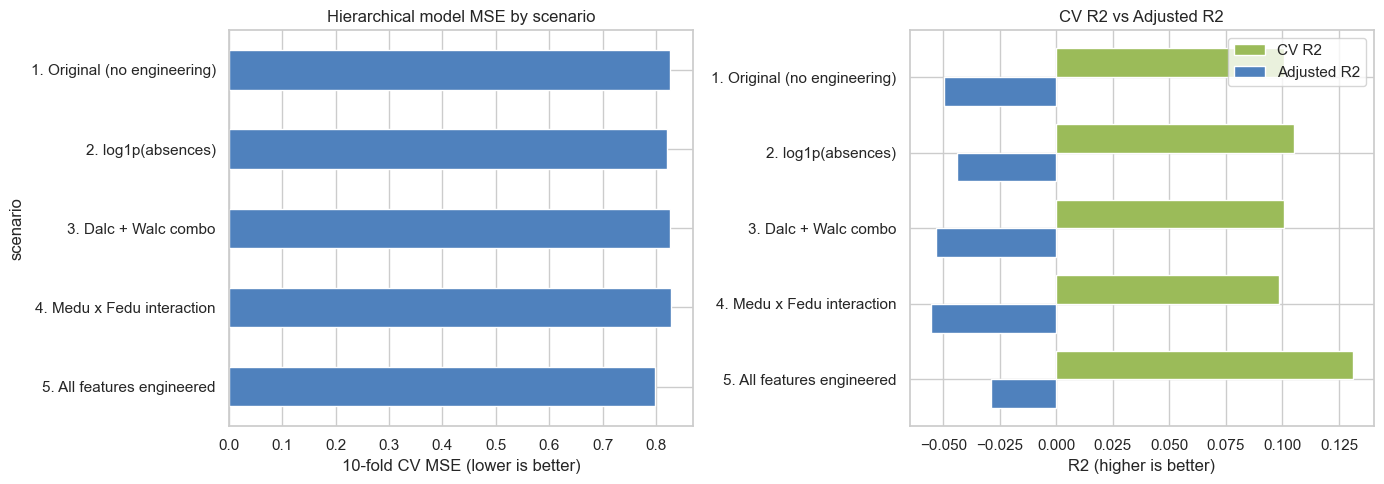

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
results["CV_MSE"].plot.barh(ax=ax[0], color="#4f81bd"); ax[0].invert_yaxis()
ax[0].set_xlabel("10-fold CV MSE (lower is better)"); ax[0].set_title("Hierarchical model MSE by scenario")

w = 0.38; ypos = np.arange(len(results))
ax[1].barh(ypos - w/2, results["CV_R2"], w, label="CV R2", color="#9bbb59")
ax[1].barh(ypos + w/2, results["Adjusted_R2"], w, label="Adjusted R2", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(results.index); ax[1].invert_yaxis()
ax[1].set_xlabel("R2 (higher is better)"); ax[1].set_title("CV R2 vs Adjusted R2"); ax[1].legend()
plt.tight_layout(); plt.show()

In [16]:
def build_engineered_v2(df, medu_fedu_mode="raw", alc_mode="raw"):
    """medu_fedu_mode: "raw" (Medu + Fedu) or "interaction" (Medu_x_Fedu only)
       alc_mode:       "raw" (Dalc + Walc) or "combo" (alc_total only)
       Never includes both sides of either pair -- that's what caused VIF = inf."""
    d = df.copy()

    # academic block unchanged: log_absences/no_absences/had_failure were all VIF < 5
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"]  = (d["absences"] == 0).astype(float)
    d["had_failure"]  = (d["failures"] > 0).astype(float)
    academic_cols = ["school", "reason", "studytime", "failures", "had_failure",
                      "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]

    # family block: EITHER raw Medu/Fedu OR the interaction -- never both
    if medu_fedu_mode == "interaction":
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols = ["Medu_x_Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    else:
        family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]

    # lifestyle block: EITHER raw Dalc/Walc OR the combined total -- never both
    if alc_mode == "combo":
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                           "internet", "freetime", "goout", "alc_total"]
    else:
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                           "internet", "freetime", "goout", "Dalc", "Walc"]

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS_V2 = {
    "A. Dalc+Walc raw  / Medu+Fedu raw":  dict(medu_fedu_mode="raw",         alc_mode="raw"),
    "B. Dalc+Walc raw  / Medu x Fedu":    dict(medu_fedu_mode="interaction", alc_mode="raw"),
    "C. alc_total      / Medu+Fedu raw":  dict(medu_fedu_mode="raw",         alc_mode="combo"),
    "D. alc_total      / Medu x Fedu":    dict(medu_fedu_mode="interaction", alc_mode="combo"),
}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)  # reuse the same folds as before

rows_v2 = []
for scenario_name, flags in SCENARIOS_V2.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered_v2(X_raw, **flags)
    df_eng["score"] = y
    metrics = run_hier_cv(df_eng, academic_cols, family_cols, lifestyle_cols, kf)
    rows_v2.append(dict(scenario=scenario_name, **metrics))

results_v2 = pd.DataFrame(rows_v2).set_index("scenario")
results_v2.round(4)

,CV_MSE,CV_R2,Adjusted_R2,n_params
scenario,,,,
A. Dalc+Walc raw / Medu+Fedu raw,0.7973,0.1326,-0.0195,47
B. Dalc+Walc raw / Medu x Fedu,0.7989,0.1307,-0.0179,46
C. alc_total / Medu+Fedu raw,0.7955,0.1343,-0.0138,46
D. alc_total / Medu x Fedu,0.7970,0.1325,-0.0121,45


## 6. Optional: refit "all features engineered" on all training data and predict `test.rds`

Not required for the comparison above, but included in case you also need test-set predictions in the same
format as `ass1.ipynb` (`predictions.rds`, a plain numeric vector). Delete this section if you only needed
the scenario comparison.

In [14]:
best_flags = SCENARIOS["5. All features engineered"]
final_df, academic_cols, family_cols, lifestyle_cols = build_engineered(X_raw, **best_flags)
final_df["score"] = y
test_df, _, _, _ = build_engineered(test, **best_flags)

blocks = {"academic": academic_cols, "family": family_cols, "lifestyle": lifestyle_cols}
final_proxies_train, final_proxies_test = {}, {}
for name, cols in blocks.items():
    sub_pipe = make_sub_pipeline(cols, final_df)
    sub_pipe.fit(final_df[cols], final_df["score"])
    final_proxies_train[f"{name}_proxy"] = sub_pipe.predict(final_df[cols])
    final_proxies_test[f"{name}_proxy"]  = sub_pipe.predict(test_df[cols])

final_master_train = pd.DataFrame(final_proxies_train, index=final_df.index)
final_master_test  = pd.DataFrame(final_proxies_test, index=test_df.index)

final_master = LinearRegression().fit(final_master_train, final_df["score"])
pred = final_master.predict(final_master_test)
assert pred.shape == (len(test_df),) and np.isfinite(pred).all()
print("Predictions:\n", pred)

Predictions:
 [ 0.63601234  0.3028152   0.75490187  0.15893633  0.03979026  0.85861222
  0.55003403  0.94878987  0.93854378  0.44553198  0.12838936  0.53624993
  0.31319492 -0.51684911  0.41416488  0.4903398   0.5659692  -0.27740531
  0.50234109 -0.00324019  0.46134034  0.40449321  0.20920732 -0.3011025
  0.17826858 -0.4120885   0.01510384 -0.31378861 -0.11221144  0.6091169
  0.22569567  0.35140279  0.03230472  0.13797493 -0.39908464 -0.31325876
  0.25483886  0.16729787  0.41789338 -0.14767956 -0.01353841  0.6627934
  0.19826719 -0.01634633 -0.52280702 -0.49068077 -0.75036463 -0.04876618
  0.24060704  0.42784706  0.15367897 -0.61608466  0.10379607  0.49506339
  0.34407256  0.08335476  0.1488963   0.69252131  0.06204494 -0.5596267
 -0.1372404   0.33860575  0.86204968  0.2301935  -0.51950623  0.52863026
  0.20008703 -1.02619011 -0.72370495 -0.14442261 -0.13162253 -0.20840406
 -0.2653917  -0.83204272  0.00986483 -0.41357392  0.24478671 -0.1164131
 -0.01822369]


In [15]:
import subprocess, shutil, glob, os

pd.Series(pred).to_csv("_pred_tmp.csv", index=False, header=False, float_format="%.10f")
rscript = shutil.which("Rscript") or (sorted(glob.glob(r"C:\\Program Files\\R\\R-*\\bin\\Rscript.exe")) or [None])[-1]
print("Rscript:", rscript)
subprocess.run([rscript, "-e",
                "x <- scan(\'_pred_tmp.csv\', quiet=TRUE); saveRDS(as.numeric(x), \'predictions.rds\'); "
                "y <- readRDS(\'predictions.rds\'); cat(\'class:\', class(y), \' length:\', length(y), \'\\n\'); print(summary(y))"],
               check=True)
os.remove("_pred_tmp.csv")

Rscript: /usr/local/bin/Rscript
class: numeric  length: 79 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.02619 -0.14605  0.14890  0.09779  0.41603  0.94879 
